# 0. Libraries

In [1]:
pip install simplemma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 MB 12.5 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import warnings

# Filter out the specific UserWarnings
warnings.filterwarnings("ignore", category=UserWarning, message="A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy")
warnings.filterwarnings("ignore", category=UserWarning, message="unable to load libtensorflow_io_plugins.so")
warnings.filterwarnings("ignore", category=UserWarning, message="file system plugins are not loaded")

In [4]:
# Accuracy metrics from Scikit-Learn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [5]:
# Hugging Face library
from datasets import Dataset, DatasetDict

In [6]:
# NLP libraries
import re
import nltk
import simplemma

from simplemma import text_lemmatizer
from nltk.corpus import stopwords

# 1. Load Dataset

In [7]:
# Create a function to import the data from csv format
def load_data(file_path):
    return pd.read_csv(file_path, header=None, delimiter='\t', names=['sentiment', 'text'])


train_path = '/kaggle/input/sentiment/train_bal_vdg_27_11.tsv'
test_path = '/kaggle/input/sentiment/test_bal_vdg_27_11.tsv'
val_path = '/kaggle/input/sentiment/valid_bal_vdg_27_11.tsv'

df_train = load_data(train_path)
df_test = load_data(test_path)
df_val = load_data(val_path)

In [8]:
def converter(df): 
    mapping = {'NEG':'negative', 'NEU':'neutral', 'POS':'positive'} 
    df['sentiment'] = df['sentiment'].replace(mapping) 
    return df

df_train = converter(df_train) 
df_val = converter(df_val) 
df_test = converter(df_test)

In [9]:
# To get an idea of the data
pd.set_option('display.max_colwidth', 150)
df_train.head()

,sentiment,text
0,neutral,"La lotta contro il bodyshaming è una cosa, promuovere l’obesità è un’altra"
1,positive,"La marginalità è un luogo radicale di possibilità, uno spazio di #resistenza. Ne parla @Racheleborghi in questo podcast pubblicato da #TRANSfemmIN..."
2,neutral,"@ilgiomba @GiovannaSerra3 @voilaloves @ArthurMeurs @LuniVale @antrichelieu @diegodemme4 @fabyo255 Io spero solo,che in cuor suo,Giovanna abbia ca..."
3,positive,Seppellire l'odio sotto una montagna di amore #ProudBoys 🧡💜💙💚♥️
4,neutral,#iorestoacasama non dimentico. E SE IO LOTTO DA PARTIGIANA Raccolta delle biografie delle partigiane a cura di @NonUnaDiMenoMI https://t.co/KUlwqE...


In [10]:
# Remove user mention here. could not do it in the preprocess function
df_train['text'] = df_train['text'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)
df_val['text'] = df_val['text'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)
df_test['text'] = df_test['text'].str.replace('@[A-Za-z0-9]+\s?', '', regex=True)

In [11]:
# I'm combining the pandas dataframe to the dataset dictionary of Hugging Face

train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)
val_dataset = Dataset.from_pandas(df_val)

# Create the DatasetDict
dataset = DatasetDict({'train': train_dataset, 'test': test_dataset, 'validation': val_dataset})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 717
    })
    test: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 216
    })
    validation: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 92
    })
})


In [12]:
# Removing duplicates

# Initialize a dictionary to store updated datasets
updated_datasets = {}

# Check for and remove duplicates in each split
for split in dataset.keys():
    split_data = dataset[split]
    
    # Access the 'text' column within the list
    text_column = split_data['text']
    
    # Initialize a set to track unique texts
    unique_texts = set()
    
    # Initialize lists to store the filtered data
    filtered_text = []
    
    # Iterate through the 'text' column and filter duplicates
    for text in text_column:
        if text not in unique_texts:
            unique_texts.add(text)
            filtered_text.append(text)
    
    # Create a new Dataset object with the filtered data
    updated_datasets[split] = split_data.select(list(range(len(filtered_text))))
    
    # Print the number of removed duplicates
    duplicate_count = len(text_column) - len(filtered_text)
    print(f"Duplicates removed in {split} split: {duplicate_count}\n")

# Update the dataset dictionary with the filtered datasets
dataset.update(updated_datasets)

# Print the updated dataset information
for split in dataset.keys():
    split_data = dataset[split]
    print(f"{split}: {len(split_data['text'])} rows")

print(dataset)

Duplicates removed in train split: 2

Duplicates removed in test split: 0

Duplicates removed in validation split: 1

train: 715 rows
test: 216 rows
validation: 91 rows
DatasetDict({
    train: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 715
    })
    test: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 216
    })
    validation: Dataset({
        features: ['sentiment', 'text'],
        num_rows: 91
    })
})


# 2. Data Prepocessing

In [13]:
italian_stopwords = set(stopwords.words('italian'))

# Define a function to preprocess text
def preprocess_text(text):    
    # Tokenization, lemmatization, removing punctuation, stopwords and URLs
    text = text_lemmatizer(text, lang='it')
    text = ' '.join(text)
    
    text = re.sub(r'[^\w\s\']', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = ' '.join(word for word in text.split() if word.lower() not in italian_stopwords)
    
    return text




def preprocess_dataset(dataset):
    dataset['text'] = preprocess_text(dataset['text'])
    return dataset

dataset = dataset.map(preprocess_dataset)

  0%|          | 0/715 [00:00<?, ?ex/s]

  0%|          | 0/216 [00:00<?, ?ex/s]

  0%|          | 0/91 [00:00<?, ?ex/s]

In [14]:
dataset['train']['text'][0:5]

['lotta bodyshaming essere cosa promuovere obesità essere altro',
 'marginalità essere luogo radicale possibilità spaziare resistenza parlare podcast pubblicare TRANSfemmINonda voce essere corpo tempo coronavirus _net',
 'sperare solo cuore Giovanna avere capire parola bullismo uso sintetizzare',
 "seppellire ' odio sotto montagna amore ProudBoys",
 'iorestoacasama dimentico lottare partigiano raccolto biografia partigiano cura']

In [15]:
# Convert the dataset to be ready for vectorization
X_train = np.array(dataset['train']['text'])
Y_train = np.array(dataset['train']['sentiment'])

X_val = np.array(dataset['validation']['text'])
Y_val = np.array(dataset['validation']['sentiment'])

X_test = np.array(dataset['test']['text'])
Y_test = np.array(dataset['test']['sentiment'])


# 3. Feature Extraction

## 3.1 BoW

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
x_train = cv.fit_transform(X_train)
x_test = cv.transform(X_test)

In [17]:
cv_matrix = x_train.toarray()
cv_vocab = cv.get_feature_names_out()

BoW = pd.DataFrame(cv_matrix,columns=cv_vocab)

In [18]:
print(BoW[['bullismo', 'violenza', 'amore', 'donna', 'stupro']])

     bullismo  violenza  amore  donna  stupro
0           0         0      0      0       0
1           0         0      0      0       0
2           1         0      0      0       0
3           0         0      1      0       0
4           0         0      0      0       0
..        ...       ...    ...    ...     ...
710         0         0      2      0       0
711         0         0      1      0       0
712         0         0      0      0       0
713         0         1      0      1       0
714         0         0      0      0       0

[715 rows x 5 columns]


## 3.2 TF-IDF 

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer()
x_train = tf.fit_transform(X_train)
x_test = tf.transform(X_test)


In [29]:
tf_matrix = x_train.toarray()
tf_vocab = tf.get_feature_names_out()

TFIDF = pd.DataFrame(tf_matrix,columns=tf_vocab)

In [30]:
print(TFIDF[['bullismo','violenza','amore','donna','stupro']])

     bullismo  violenza     amore     donna  stupro
0    0.000000  0.000000  0.000000  0.000000     0.0
1    0.000000  0.000000  0.000000  0.000000     0.0
2    0.194824  0.000000  0.000000  0.000000     0.0
3    0.000000  0.000000  0.201374  0.000000     0.0
4    0.000000  0.000000  0.000000  0.000000     0.0
..        ...       ...       ...       ...     ...
710  0.000000  0.000000  0.230597  0.000000     0.0
711  0.000000  0.000000  0.183230  0.000000     0.0
712  0.000000  0.000000  0.000000  0.000000     0.0
713  0.000000  0.157871  0.000000  0.165417     0.0
714  0.000000  0.000000  0.000000  0.000000     0.0

[715 rows x 5 columns]


# 4. Support Vector Machine

In [31]:
# LinearSVC
from sklearn.svm import SVC
svm = SVC(random_state=0)

In [32]:
svm.fit(x_train,Y_train)

y_test_svm=svm.predict(x_test)

# 5. Naive Bayes

In [33]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()

In [34]:
nb.fit(x_train,Y_train)

y_test_nb=nb.predict(x_test)

# 6. Metrics

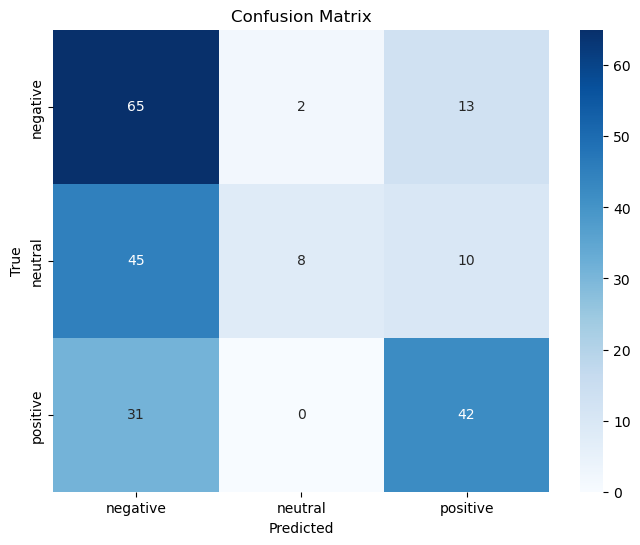

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute the confusion matrix
conf_matrix = confusion_matrix(Y_test, y_test_nb, labels=['negative', 'neutral', 'positive'])

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [36]:
report_svm = classification_report(Y_test, y_test_svm)

report_nb = classification_report(Y_test, y_test_nb)

print("Support Vector Machine Classification Report:")
print(report_svm)

print("\nNaive Bayes Classification Report:")
print(report_nb)

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

    negative       0.50      0.76      0.61        80
     neutral       0.56      0.22      0.32        63
    positive       0.61      0.59      0.60        73

    accuracy                           0.55       216
   macro avg       0.56      0.52      0.51       216
weighted avg       0.56      0.55      0.52       216


Naive Bayes Classification Report:
              precision    recall  f1-score   support

    negative       0.46      0.81      0.59        80
     neutral       0.80      0.13      0.22        63
    positive       0.65      0.58      0.61        73

    accuracy                           0.53       216
   macro avg       0.64      0.50      0.47       216
weighted avg       0.62      0.53      0.49       216



In [25]:
accuracy_svm = accuracy_score(Y_test, y_test_svm) # (TP+TN)/P+N i.e total number of corrected classified tweet over total number of tweets

accuracy_nb = accuracy_score(Y_test, y_test_nb)

print("Support Vector Machine accuracy:", accuracy_svm)
print("Naive Bayes accuracy:", accuracy_nb)

Support Vector Machine accuracy: 0.5509259259259259
Naive Bayes accuracy: 0.5416666666666666


In [26]:
precision_svm = precision_score(Y_test, y_test_svm,average=None, labels=['negative','neutral','positive']) # TP/(TP+FP) i.e if predicted a certain class, which is the probability of being really that class?

precision_nb = precision_score(Y_test, y_test_nb,average=None, labels=['negative','neutral','positive'])

print("Support Vector Machine precision:", precision_svm)
print("Naive Bayes precision:", precision_nb)

Support Vector Machine precision: [0.61643836 0.48192771 0.56666667]
Naive Bayes precision: [0.51260504 0.5625     0.58461538]


In [27]:
recall_svm = recall_score(Y_test, y_test_svm,average=None, labels=['negative','neutral','positive']) # TP/(TP+FN) i.e the ability of the estimator to predict all the tweets of a given class

recall_nb = recall_score(Y_test, y_test_nb,average=None, labels=['negative','neutral','positive'])


print("Support Vector Machine recall:", recall_svm)
print("Naive Bayes recall:", recall_nb)

Support Vector Machine recall: [0.5625     0.63492063 0.46575342]
Naive Bayes recall: [0.7625     0.28571429 0.52054795]


In [ ]:
f1score_svm = f1_score(Y_test, y_test_svm,average=None, labels=['negative','neutral','positive']) # 2*(precision*recall)/(precision+recall)

f1score_nb = f1_score(Y_test, y_test_nb,average=None, labels=['negative','neutral','positive'])


print("Support Vector Machine f1-score:", f1score_svm)
print("Naive Bayes f1-score:", f1score_nb)